In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import torch
from pathlib import Path
import os
import pickle
import math
from collections import OrderedDict
sys.path.append(str(Path.cwd().parent))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
def plot_multiple_regression_series(data_dicts, titles=None, save_path=None, verbose=False):
    """
    data_dicts: list of data_dict，每个 data_dict 结构为 {label: (true_vals, pred_vals)}
    titles: list of str，与 data_dicts 对应的子图标题
    """
    n = len(data_dicts)
    cols = 2 if n > 1 else 1
    rows = math.ceil(n / cols)   
    

    fig, axs = plt.subplots(rows, cols, figsize=(8*cols, 5*rows), squeeze=False)
    axs = axs.ravel()

    all_handles, all_labels = [], []  # 用于合并图例

    for i, data_dict in enumerate(data_dicts):
        ax = axs[i]
        idx_start = 0
        for label, (true_vals, pred_vals) in data_dict.items():
            n_pts = len(true_vals)
            idx_range = np.arange(idx_start, idx_start + n_pts)

            h1, = ax.plot(idx_range, true_vals, label=f'{label} - True')
            h2, = ax.plot(idx_range, pred_vals, linestyle='--', label=f'{label} - Predicted')

            idx_start += n_pts

            all_handles.extend([h1, h2])
            all_labels.extend([h1.get_label(), h2.get_label()])

        ax.set_xlabel("Sample Index", fontsize=12)
        ax.set_ylabel("Magnitude", fontsize=12)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=14)
        ax.grid(True)
        
    uniq = dict(zip(all_labels, all_handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=4, fontsize=12)

    plt.tight_layout(rect=[0,0.05,1,1])  # 留出底部空间放图例

    if save_path:
        plt.savefig(save_path, dpi=120)
        if verbose:
            print(f"[✔] Saved series plots to {save_path}")
    plt.show()

In [3]:
from  src.train.config_setup import load_and_prepare_model
from src.data.preparation import prepare_data, prepare_data_lstm  
from src.train.regressor_train_step import  get_data_dict
def get_data_dict_from_checkpoint(checkpoint_path_list, device, prepare_data_func, shared_data=None):
    """
    Given a checkpoint path, load the model and prepare the data dictionary.
    If shared_data is provided, reuse it instead of preparing new data.
    """
    data_dict_list = []
    for checkpoint_path in checkpoint_path_list:
        model, args = load_and_prepare_model(checkpoint_path=checkpoint_path, device=device)
        if shared_data is None:
            df, train_loader, val_loader, test_loader, catalog_ds = prepare_data_func(
                base_dir=f"../data/{args.dataset}", args=args
            )
            shared_data = (train_loader, val_loader, test_loader)
        else:
            train_loader, val_loader, test_loader = shared_data
        data_dict = get_data_dict([train_loader, val_loader, test_loader], model, device)
        data_dict_list.append(data_dict)
    return data_dict_list

In [4]:
checkpoint_path_lstm = [
     Path("../checkpoints/lstm_20250906-152053/last_model_1.pth"),
    
]
checkpoint_path_reg = [
    Path("../checkpoints/reg_mixer_attnpl_t_20250907-183220/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20250907-133839/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20250906-205258/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20250906-211115/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20250906-204638/last_model_1.pth")
]

lstm_data_dicts = get_data_dict_from_checkpoint(checkpoint_path_lstm, device, prepare_data_lstm)
reg_data_dicts = get_data_dict_from_checkpoint(checkpoint_path_reg, device, prepare_data)
data_dicts = lstm_data_dicts+ reg_data_dicts


load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'lstm', 'task_type': 'regression', 'batch_size': 128, 'accumulation_steps': 1, 'warmup_ratio': 'None', 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': 0.6, 'scheduler_patience': 5, 'scheduler_threshold': 0.0001, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'lstm_hidden_size': 256, 'lstm_num_layers': 4, 'lstm_dropout': 0.3, 'epochs': 200, 'save_dir': 'checkpoints/lstm_20250906-152053', 'cuda_id': '0', 'dataset': 'ChuanDian', 'criterion_name': 'smooth_l1', 'criterion_cfg': {'beta': 0.5}, 'seed': 0, 'Mc': 3, 'Mf': 3, 'Mag_elaps': [6, 6.5, 7, 7.5], 'Twindow': 360, 'Tfore': 180, 'dt': 10, 'context_len': 0, 'dMag': 0.1, 'split_by_time': True, 'time_step': 5, 'feature_cols': ['Num', 'Mag_max', 'Mag_mean', 'b_lsq', 'a_lsq', 'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk', 'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk', 'beta'

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0909 17:02:00.097000 3495 site-packages/torch/_dynamo/convert_frame.py:844] [4/8] torch._dynamo hit config.cache_size_limit (8)
W0909 17:02:00.097000 3495 site-packages/torch/_dynamo/convert_frame.py:844] [4/8]    function: 'forward' (/root/autodl-tmp/chuandian_eq/src/models/mamba/block.py:43)
W0909 17:02:00.097000 3495 site-packages/torch/_dynamo/convert_frame.py:844] [4/8]    last reason: 4/0: ___check_obj_id(L['residual'], 9667616)                     
W0909 17:02:00.097000 3495 site-packages/torch/_dynamo/convert_frame.py:844] [4/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0909 17:02:00.097000 3495 site-packages/torch/_dynamo/convert_frame.py:844] [4/8] To diagnose recompilation

using time scale base 1.3070542199341526 (key: tau_mean)
tau mean: 1.3070541620254517
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 2, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.5, 'd_model': 64, 'mixer_model_config': {'input_dim': 2, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 3, 'd_intermediate': 128, 'attn_layer_idx': [1], 'ssm_cfg': {'layer': 'Mamba2Rotary', 'd_conv': 4, 'use_conv': True, 'rotary_emb_scale_base': 1024}, 'attn_cfg': {'layer': 'MHATime', 'num_heads': 4, 'rotary_emb_dim': 8, 'rot

In [5]:
os.makedirs("figs_data", exist_ok=True)
with open("figs_data/reg_data_dicts.pkl", "wb") as f:
    pickle.dump(data_dicts, f)

In [6]:
with open("figs_data/reg_data_dicts.pkl", "rb") as f:  # "rb" 表示以二进制只读模式
    data_dicts = pickle.load(f)

In [7]:
titles = [
    "LSTM ",
    "REG",
    "-TXPOS ",
    "-TMAP",
    "-Pretraining",
    "+log"
]

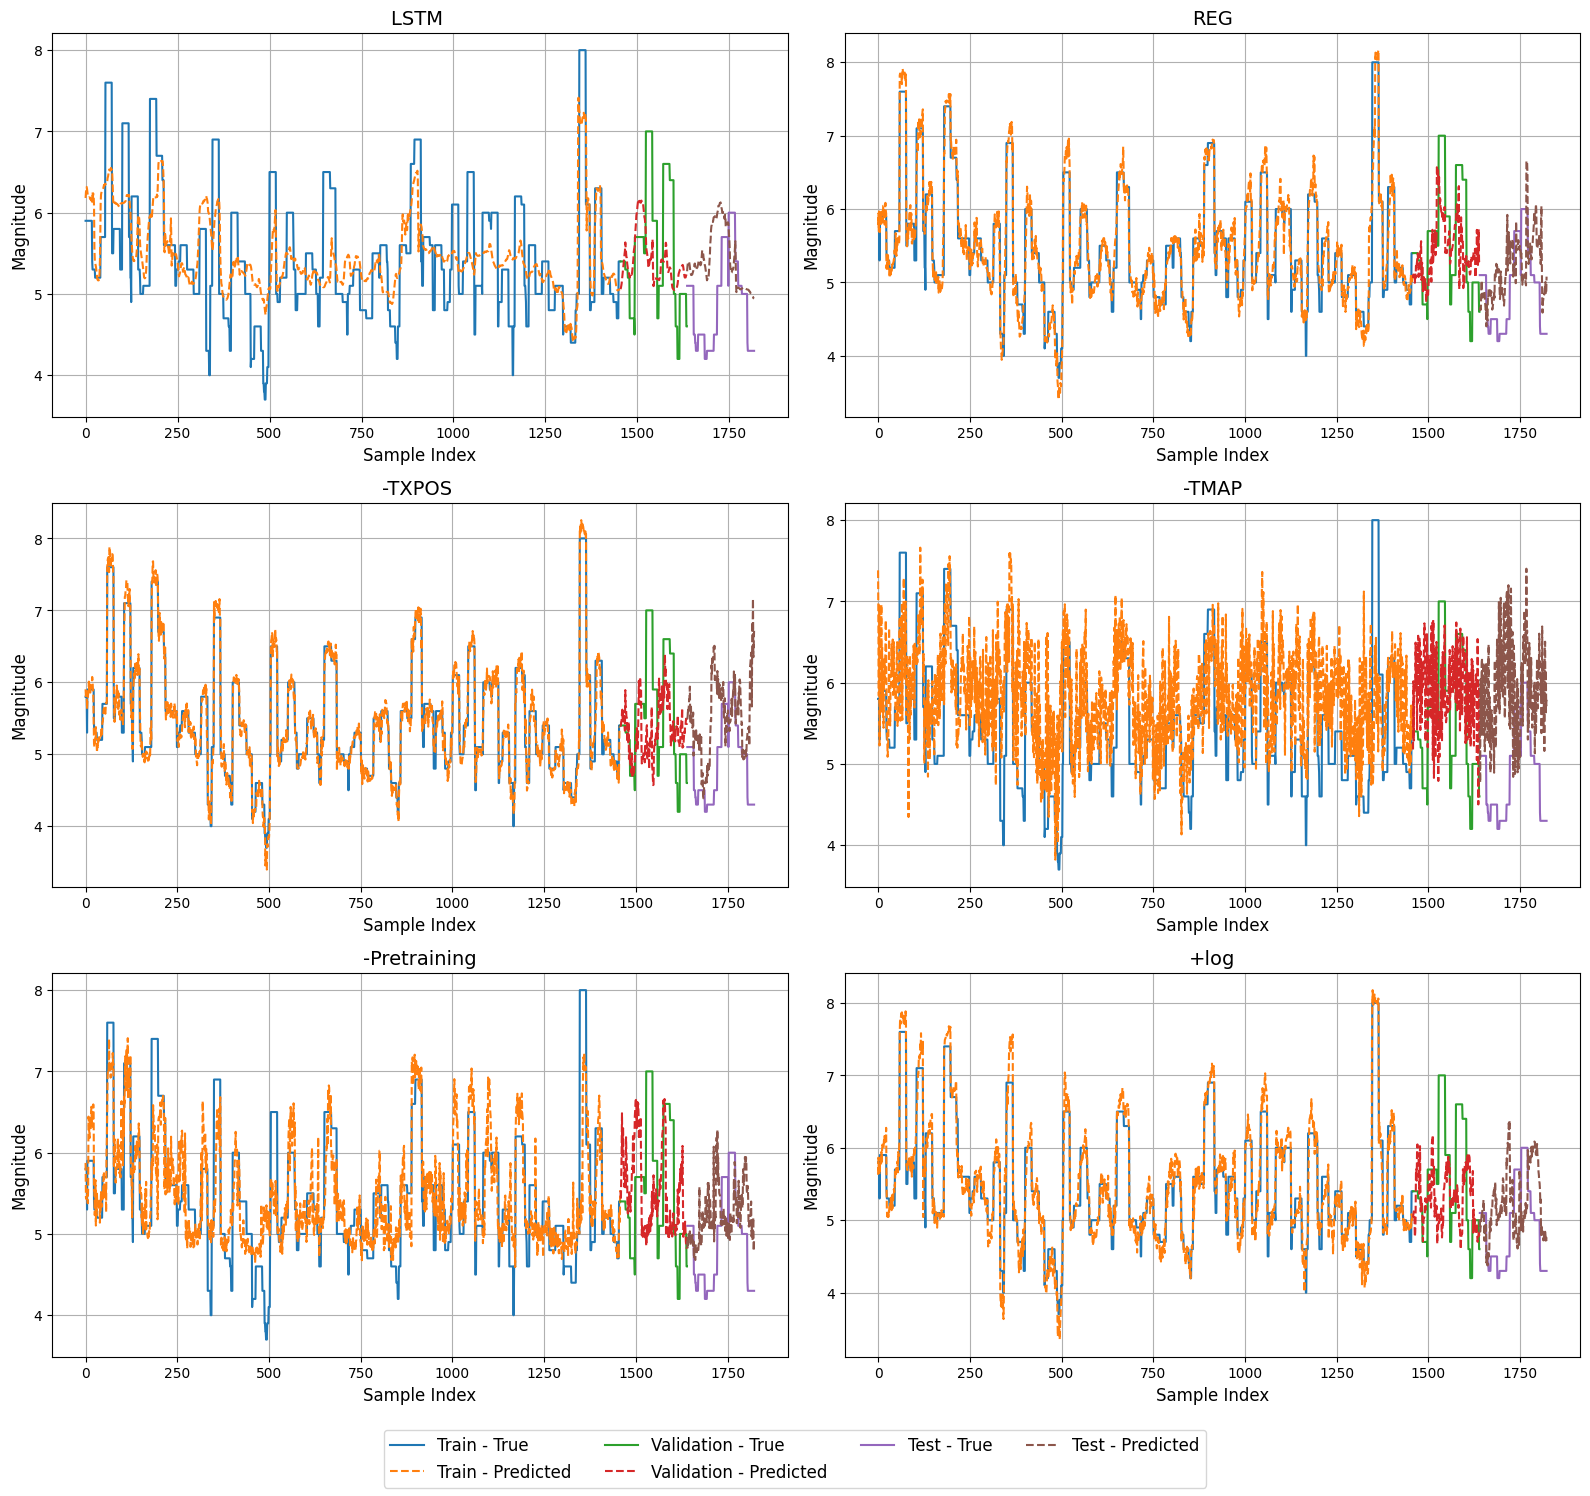

In [8]:
plot_multiple_regression_series(data_dicts , titles=titles, save_path="figs/regression_plots.png", verbose=False)